In [9]:
import numpy as np
import matplotlib.pyplot as plt


Nodal Displacements (ux [mm], uy [mm], theta_z [rad], theta_z [mrad])
Node  1 (x=    0.0, y=    0.0) : ux= 0.000000e+00 mm, uy= 0.000000e+00 mm, thz= 0.000000e+00 rad ( 0.000000e+00 mrad)
Node  2 (x= 6000.0, y=    0.0) : ux= 0.000000e+00 mm, uy= 0.000000e+00 mm, thz= 0.000000e+00 rad ( 0.000000e+00 mrad)
Node  3 (x=12000.0, y=    0.0) : ux= 0.000000e+00 mm, uy= 0.000000e+00 mm, thz= 0.000000e+00 rad ( 0.000000e+00 mrad)
Node  4 (x=18000.0, y=    0.0) : ux= 0.000000e+00 mm, uy= 0.000000e+00 mm, thz= 0.000000e+00 rad ( 0.000000e+00 mrad)
Node  5 (x=    0.0, y= 3000.0) : ux= 2.644481e+00 mm, uy= 2.199165e-02 mm, thz=-9.186072e-04 rad (-9.186072e-01 mrad)
Node  6 (x= 6000.0, y= 3000.0) : ux= 2.602026e+00 mm, uy=-2.654817e-03 mm, thz=-6.955118e-04 rad (-6.955118e-01 mrad)
Node  7 (x=12000.0, y= 3000.0) : ux= 2.572572e+00 mm, uy= 2.523710e-03 mm, thz=-6.915849e-04 rad (-6.915849e-01 mrad)
Node  8 (x=18000.0, y= 3000.0) : ux= 2.555205e+00 mm, uy=-2.186054e-02 mm, thz=-8.998606e-04 rad (-8.99

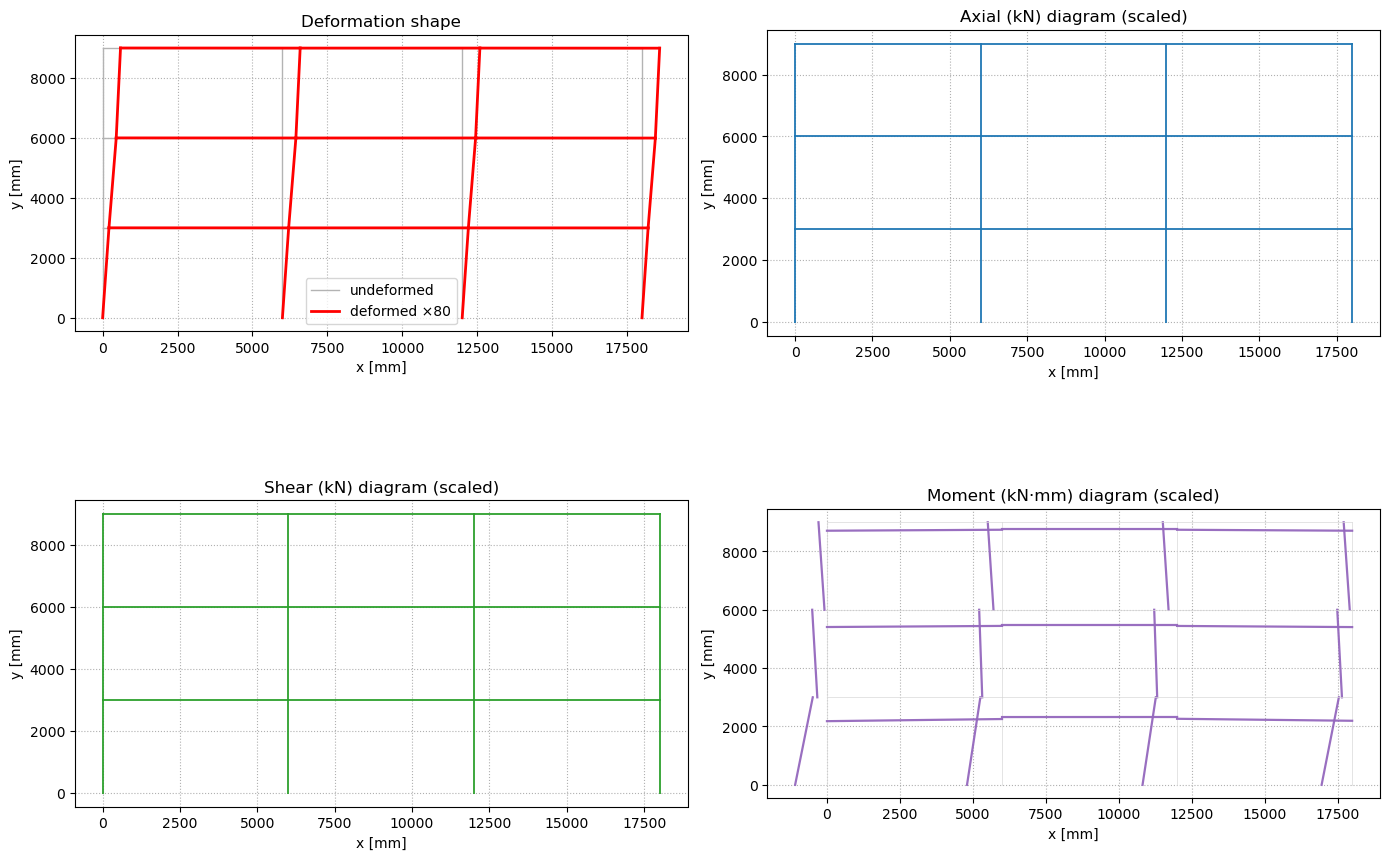


Summary:
Max |ux| = 7.461357e+00 mm at node 13
Max |uy| = 3.712446e-02 mm at node 13
Max |theta| = 9.186072e-04 rad at node 5
Max |N| = 41.874471 kN
Max |V| = 42.007973 kN
Max |M| = 77849.543959 kN·mm


In [10]:
# ------------------------------------------------------------
# 2D Multi-span frame FEM (Timoshenko frame element)
# Units: N, mm, rad
# Geometry: 3 bays @ 6000 mm, 3 stories @ 3000 mm
# Nodes: 4 x-positions, 4 y-positions = 16 nodes
# Elements: 12 columns + 9 beams = 21
# Material: E = 3.0e4 MPa = 30000 N/mm^2, nu=0.3, G = E/(2(1+nu))
# Section: 400 x 400 mm, A = 160000 mm^2, Iz = b*h^3/12 = 2.133333333e9 mm^4
# Boundary: fixed at y=0 nodes; Loads: Fx=+50 kN at nodes (1,2),(1,3),(1,4)
# ------------------------------------------------------------

np.set_printoptions(precision=6, suppress=True)

# Geometry
Lbay = 6000.0
Hstory = 3000.0
x_positions = [0.0, 6000.0, 12000.0, 18000.0]  # i = 1..4
y_positions = [0.0, 3000.0, 6000.0, 9000.0]    # j = 1..4
nx = len(x_positions)
ny = len(y_positions)
nnodes = nx * ny
ndof_per_node = 3
ndof = nnodes * ndof_per_node

def node_id(i, j):
    # i, j zero-based (i=0..3, j=0..3)
    return j * nx + i

nodes = np.zeros((nnodes, 2))
for j, y in enumerate(y_positions):
    for i, x in enumerate(x_positions):
        nid = node_id(i, j)
        nodes[nid, :] = [x, y]

# Elements: columns (vertical) and beams (horizontal)
# Each element: (n1, n2)
elements = []

# Columns: i=0..3, j=0..2; connects (i,j) -> (i,j+1)
for i in range(nx):
    for j in range(ny - 1):
        n1 = node_id(i, j)
        n2 = node_id(i, j + 1)
        elements.append((n1, n2))

# Beams: floors j=1..3 (i.e., y_positions[1:]), spans i=0..2; connects (i,j)->(i+1,j)
for j in range(1, ny):
    for i in range(nx - 1):
        n1 = node_id(i, j)
        n2 = node_id(i + 1, j)
        elements.append((n1, n2))

nelem = len(elements)
assert nelem == 21, f"Expected 21 elements, got {nelem}"

# Material and section
E = 3.0e4  # MPa -> N/mm^2
nu = 0.3
G = E / (2.0 * (1.0 + nu))
b = 400.0
h = 400.0
A = b * h  # 160000 mm^2
Iz = b * h**3 / 12.0  # 2.1333333e9 mm^4
kappa = 5.0 / 6.0  # shear correction factor

# DOF helpers
def dof_idx(n):
    # returns [ux, uy, rz] indices in global DOF
    base = n * ndof_per_node
    return [base + 0, base + 1, base + 2]

# Timoshenko frame element stiffness (local)
def timoshenko_frame_k_local(E, G, A, I, kappa, L):
    # Axial
    k_ax = E * A / L
    # Shear-flexible bending
    phi = 12.0 * E * I / (kappa * G * A * L**2)
    c1 = E * I / (L * (1.0 + phi))
    k22 = 12.0 * E * I / (L**3 * (1.0 + phi))
    k23 = 6.0 * E * I / (L**2 * (1.0 + phi))
    k33 = (4.0 + phi) * c1
    k34 = (2.0 - phi) * c1

    k = np.zeros((6, 6))
    # local DOFs order: [u1, v1, th1, u2, v2, th2]
    k[0, 0] =  k_ax
    k[0, 3] = -k_ax
    k[3, 0] = -k_ax
    k[3, 3] =  k_ax

    k[1, 1] =  k22
    k[1, 2] =  k23
    k[1, 4] = -k22
    k[1, 5] =  k23

    k[2, 1] =  k23
    k[2, 2] =  k33
    k[2, 4] = -k23
    k[2, 5] =  k34

    k[4, 1] = -k22
    k[4, 2] = -k23
    k[4, 4] =  k22
    k[4, 5] = -k23

    k[5, 1] =  k23
    k[5, 2] =  k34
    k[5, 4] = -k23
    k[5, 5] =  k33
    return k

# Transformation matrix from local to global for 2D frame
def transform_T(n1, n2):
    x1, y1 = nodes[n1]
    x2, y2 = nodes[n2]
    dx = x2 - x1
    dy = y2 - y1
    L = np.hypot(dx, dy)
    c = dx / L
    s = dy / L
    T = np.zeros((6, 6))
    T[0, 0] =  c; T[0, 1] =  s
    T[1, 0] = -s; T[1, 1] =  c
    T[2, 2] =  1.0
    T[3, 3] =  c; T[3, 4] =  s
    T[4, 3] = -s; T[4, 4] =  c
    T[5, 5] =  1.0
    return T, L, c, s

# Assembly
K = np.zeros((ndof, ndof))
for e, (n1, n2) in enumerate(elements):
    T, L, c, s = transform_T(n1, n2)
    k_local = timoshenko_frame_k_local(E, G, A, Iz, kappa, L)
    k_global = T.T @ k_local @ T

    dofs = dof_idx(n1) + dof_idx(n2)
    for a in range(6):
        Aidx = dofs[a]
        for b in range(6):
            Bidx = dofs[b]
            K[Aidx, Bidx] += k_global[a, b]

# Load vector
F = np.zeros(ndof)

# Apply 50 kN horizontal at nodes (1,2), (1,3), (1,4)
# In zero-based (i,j): (0,1), (0,2), (0,3)
load_nodes = [node_id(0, 1), node_id(0, 2), node_id(0, 3)]
for n in load_nodes:
    F[dof_idx(n)[0]] += 50_000.0  # N in +x

# Boundary conditions: fully fixed at j=0 (bottom) for all i
fixed_dofs = []
for i in range(nx):
    n = node_id(i, 0)  # j=0 bottom nodes
    fixed_dofs += dof_idx(n)

all_dofs = np.arange(ndof, dtype=int)
free_dofs = np.setdiff1d(all_dofs, np.array(fixed_dofs, dtype=int))

# Solve
K_ff = K[np.ix_(free_dofs, free_dofs)]
F_f = F[free_dofs]

# Since all fixed prescribed displacements are zero, right-hand side is just F_f
u = np.zeros(ndof)
u_f = np.linalg.solve(K_ff, F_f)
u[free_dofs] = u_f

# Reactions
R = K @ u - F  # reactions at all DOFs; only nonzero at fixed DOFs ideally

# Post-process: element end forces in local axes [N1, V1, M1, N2, V2, M2]
elem_end_forces_local = []
for (n1, n2) in elements:
    T, L, c, s = transform_T(n1, n2)
    k_local = timoshenko_frame_k_local(E, G, A, Iz, kappa, L)
    dofs = dof_idx(n1) + dof_idx(n2)
    u_e_global = u[dofs]
    u_e_local = T @ u_e_global
    f_e_local = k_local @ u_e_local  # no fixed-end forces (no distributed loads)
    elem_end_forces_local.append(f_e_local)

elem_end_forces_local = np.array(elem_end_forces_local)

# Reporting
def print_results():
    print("\nNodal Displacements (ux [mm], uy [mm], theta_z [rad], theta_z [mrad])")
    for n in range(nnodes):
        ux = u[dof_idx(n)[0]]
        uy = u[dof_idx(n)[1]]
        th = u[dof_idx(n)[2]]
        print(f"Node {n+1:2d} (x={nodes[n,0]:7.1f}, y={nodes[n,1]:7.1f}) : "
              f"ux={ux: .6e} mm, uy={uy: .6e} mm, thz={th: .6e} rad ({th*1e3: .6e} mrad)")

    print("\nSupport Reactions at fixed DOFs (Fx [kN], Fy [kN], Mz [kN·mm]) per node")
    # Aggregate reactions per node at fixed supports
    reactions_per_node = {}
    for i in range(nx):
        n = node_id(i, 0)
        dofsn = dof_idx(n)
        Rx = R[dofsn[0]] / 1000.0
        Ry = R[dofsn[1]] / 1000.0
        Mz = R[dofsn[2]] / 1000.0  # in kN*mm
        reactions_per_node[n+1] = (Rx, Ry, Mz)
    for n1 in sorted(reactions_per_node.keys()):
        Rx, Ry, Mz = reactions_per_node[n1]
        print(f"Node {n1:2d}: Rx={Rx: .6f} kN, Ry={Ry: .6f} kN, Mz={Mz: .6f} kN·mm")

    print("\nElement End Forces (Local) [N (kN), V (kN), M (kN·mm)]")
    print("Format: e_id: (n1 -> n2)  [N1, V1, M1 | N2, V2, M2]")
    for e, (n1, n2) in enumerate(elements):
        f = elem_end_forces_local[e]
        N1, V1, M1, N2, V2, M2 = f
        print(f"e{e+1:2d}: ({n1+1:2d} -> {n2+1:2d}) "
              f"[{N1/1e3: .6f}, {V1/1e3: .6f}, {M1/1e3: .6f} | "
              f"{N2/1e3: .6f}, {V2/1e3: .6f}, {M2/1e3: .6f}] (kN, kN, kN·mm)")

print_results()

# Visualization
def plot_frame(ax, nodes, elements, color='k', lw=1.5, label=None):
    for (n1, n2) in elements:
        x = [nodes[n1, 0], nodes[n2, 0]]
        y = [nodes[n1, 1], nodes[n2, 1]]
        ax.plot(x, y, color=color, lw=lw)
    if label:
        ax.plot([], [], color=color, lw=lw, label=label)

def plot_deformation(ax, nodes, elements, u, scale=80.0):
    # scale: amplification for visualization
    deformed = nodes.copy()
    for n in range(nnodes):
        deformed[n, 0] += u[dof_idx(n)[0]] * scale
        deformed[n, 1] += u[dof_idx(n)[1]] * scale
    plot_frame(ax, nodes, elements, color='0.7', lw=1.0, label='undeformed')
    plot_frame(ax, deformed, elements, color='r', lw=2.0, label=f'deformed ×{scale:g}')
    ax.set_aspect('equal', adjustable='box')
    ax.set_title('Deformation shape')
    ax.legend()
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.grid(True, ls=':')

def plot_internal_diagram(ax, nodes, elements, end_forces, kind='M'):
    # kind: 'N' (axial), 'V' (shear), 'M' (moment)
    # Compute global unit vectors along (t) and normal (n) to each element
    # For diagram scaling
    if kind == 'M':
        vals = np.abs(end_forces[:, [2, 5]])  # M1, M2
    elif kind == 'V':
        vals = np.abs(end_forces[:, [1, 4]])  # V1, V2 (constant if no dist loads)
    elif kind == 'N':
        vals = np.abs(end_forces[:, [0, 3]])  # N1, N2 (constant)
    vmax = np.max(vals) if vals.size else 1.0
    if vmax < 1e-12:
        vmax = 1.0

    # Target max offset in mm for visibility
    if kind == 'M':
        target = 1200.0
        label = 'Moment (kN·mm)'
        color = 'tab:purple'
    elif kind == 'V':
        target = 600.0
        label = 'Shear (kN)'
        color = 'tab:green'
    elif kind == 'N':
        target = 600.0
        label = 'Axial (kN)'
        color = 'tab:blue'

    scale = target / vmax

    for e, (n1, n2) in enumerate(elements):
        x1, y1 = nodes[n1]
        x2, y2 = nodes[n2]
        dx = x2 - x1
        dy = y2 - y1
        L = np.hypot(dx, dy)
        if L == 0:
            continue
        tx = dx / L
        ty = dy / L
        nxv = -ty  # normal unit vector components
        nyv = tx

        f = end_forces[e]
        N1, V1, M1, N2, V2, M2 = f

        if kind == 'N':
            val = 0.5 * (N1 + N2)  # constant; take average
            offs = scale * val
            # Use sign: tension positive -> draw to +normal
            p1 = np.array([x1, y1]) + offs * np.array([nxv, nyv])
            p2 = np.array([x2, y2]) + offs * np.array([nxv, nyv])
            ax.plot([x1, x2, p2[0], p1[0], x1],
                    [y1, y2, p2[1], p1[1], y1],
                    color=color, lw=1.2, alpha=0.9)
        elif kind == 'V':
            val = 0.5 * (V1 + V2)  # constant
            offs = scale * val
            p1 = np.array([x1, y1]) + offs * np.array([nxv, nyv])
            p2 = np.array([x2, y2]) + offs * np.array([nxv, nyv])
            ax.plot([x1, x2, p2[0], p1[0], x1],
                    [y1, y2, p2[1], p1[1], y1],
                    color=color, lw=1.2, alpha=0.9)
        elif kind == 'M':
            # Linear variation along element from M1 to M2
            npts = 10
            xs = []
            ys = []
            for k in range(npts + 1):
                s = (k / npts) * L
                M = M1 * (1 - s / L) + M2 * (s / L)
                offs = scale * M
                px = x1 + tx * s + nxv * offs
                py = y1 + ty * s + nyv * offs
                xs.append(px)
                ys.append(py)
            # close to base line ends
            ax.plot([x1, x2], [y1, y2], color='0.85', lw=0.5)
            ax.plot(xs, ys, color=color, lw=1.6, alpha=0.95)

    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'{label} diagram (scaled)')
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.grid(True, ls=':')

def make_plots():
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    # Deformation
    plot_deformation(axs[0, 0], nodes, elements, u, scale=80.0)
    # Axial, Shear, Moment
    plot_internal_diagram(axs[0, 1], nodes, elements, elem_end_forces_local, kind='N')
    plot_internal_diagram(axs[1, 0], nodes, elements, elem_end_forces_local, kind='V')
    plot_internal_diagram(axs[1, 1], nodes, elements, elem_end_forces_local, kind='M')
    plt.tight_layout()
    plt.show()

make_plots()

# Optional: print a compact summary of maximums
def summary():
    ux = u[0::3]
    uy = u[1::3]
    th = u[2::3]
    print("\nSummary:")
    print(f"Max |ux| = {np.max(np.abs(ux)):.6e} mm at node {np.argmax(np.abs(ux))+1}")
    print(f"Max |uy| = {np.max(np.abs(uy)):.6e} mm at node {np.argmax(np.abs(uy))+1}")
    print(f"Max |theta| = {np.max(np.abs(th)):.6e} rad at node {np.argmax(np.abs(th))+1}")
    # Internal forces
    Nmax = np.max(np.abs(elem_end_forces_local[:, [0, 3]]))
    Vmax = np.max(np.abs(elem_end_forces_local[:, [1, 4]]))
    Mmax = np.max(np.abs(elem_end_forces_local[:, [2, 5]]))
    print(f"Max |N| = {Nmax/1e3:.6f} kN")
    print(f"Max |V| = {Vmax/1e3:.6f} kN")
    print(f"Max |M| = {Mmax/1e3:.6f} kN·mm")

summary()


SAVING NODE DISPLACEMENTS TO CSV
Node displacement data saved to 'node_displacements_3_timoshenko.csv'

CSV文件包含 16 个节点的数据

前10个节点的数据:
 Node Node_Coord       X      Y   Z  Fixed  Loaded       U1        U2  U3  UR1  UR2       UR3  Total_Displacement
    1      (1,1)     0.0    0.0 0.0      1       0 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    2      (2,1)  6000.0    0.0 0.0      1       0 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    3      (3,1) 12000.0    0.0 0.0      1       0 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    4      (4,1) 18000.0    0.0 0.0      1       0 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    5      (1,2)     0.0 3000.0 0.0      0       1 2.644481  0.021992 0.0  0.0  0.0 -0.000919            2.644572
    6      (2,2)  6000.0 3000.0 0.0      0       0 2.602026 -0.002655 0.0  0.0  0.0 -0.000696            2.602027
    7      (3,2) 12000.0 3000.0 0.0      0       0 2.572572  0.0025

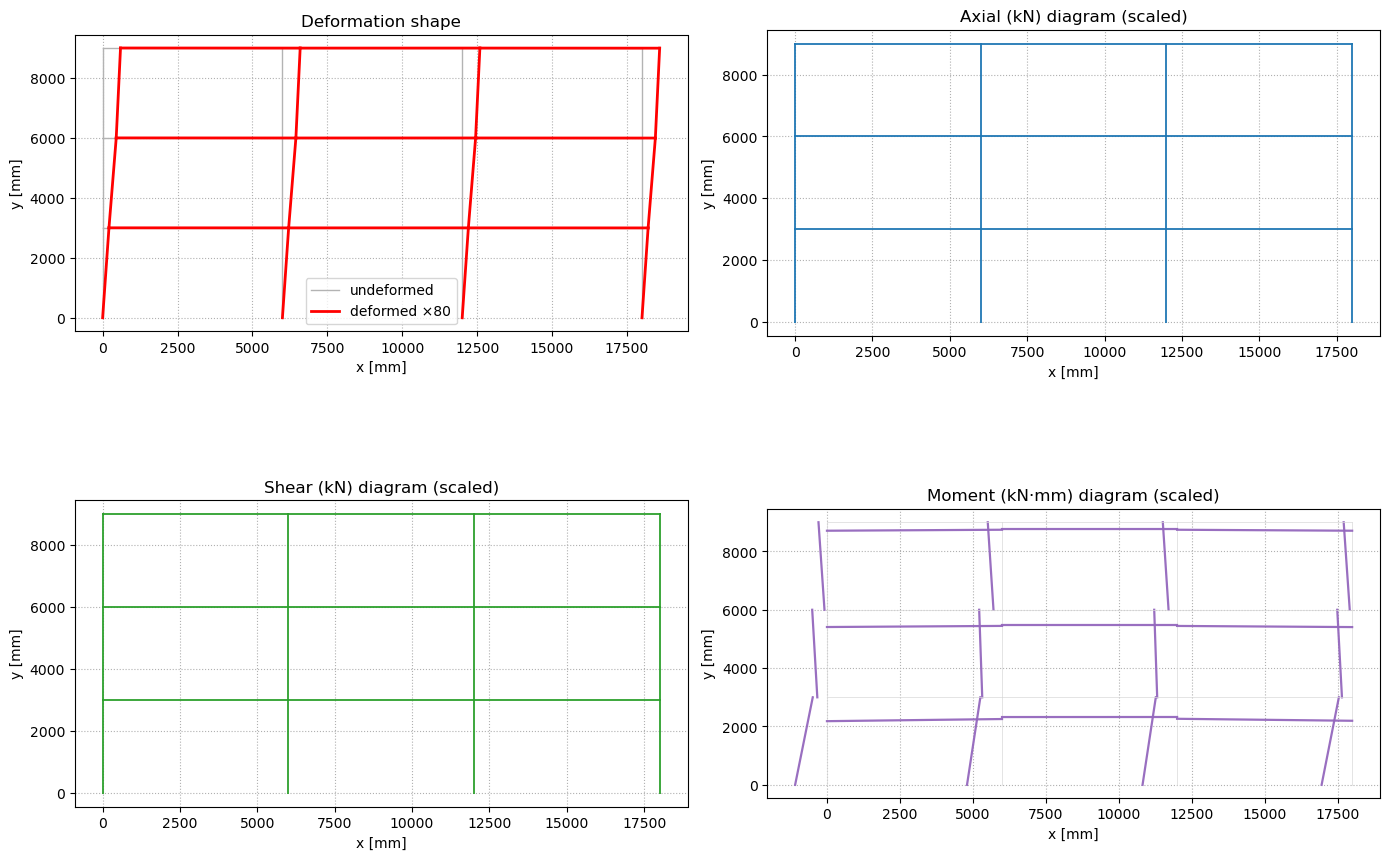


Summary:
Max |ux| = 7.461357e+00 mm at node 13
Max |uy| = 3.712446e-02 mm at node 13
Max |theta| = 9.186072e-04 rad at node 5
Max |N| = 41.874471 kN
Max |V| = 42.007973 kN
Max |M| = 77849.543959 kN·mm


In [11]:
# 首先在文件开头添加必要的导入
import csv
import pandas as pd

# ------------------------------------------------------------
# 2D Multi-span frame FEM (Timoshenko frame element)
# Units: N, mm, rad
# Geometry: 3 bays @ 6000 mm, 3 stories @ 3000 mm
# Nodes: 4 x-positions, 4 y-positions = 16 nodes
# Elements: 12 columns + 9 beams = 21
# Material: E = 3.0e4 MPa = 30000 N/mm^2, nu=0.3, G = E/(2(1+nu))
# Section: 400 x 400 mm, A = 160000 mm^2, Iz = b*h^3/12 = 2.133333333e9 mm^4
# Boundary: fixed at y=0 nodes; Loads: Fx=+50 kN at nodes (1,2),(1,3),(1,4)
# ------------------------------------------------------------

np.set_printoptions(precision=6, suppress=True)

# Geometry
Lbay = 6000.0
Hstory = 3000.0
x_positions = [0.0, 6000.0, 12000.0, 18000.0]  # i = 1..4
y_positions = [0.0, 3000.0, 6000.0, 9000.0]    # j = 1..4
nx = len(x_positions)
ny = len(y_positions)
nnodes = nx * ny
ndof_per_node = 3
ndof = nnodes * ndof_per_node

def node_id(i, j):
    # i, j zero-based (i=0..3, j=0..3)
    return j * nx + i

nodes = np.zeros((nnodes, 2))
for j, y in enumerate(y_positions):
    for i, x in enumerate(x_positions):
        nid = node_id(i, j)
        nodes[nid, :] = [x, y]

# Elements: columns (vertical) and beams (horizontal)
# Each element: (n1, n2)
elements = []

# Columns: i=0..3, j=0..2; connects (i,j) -> (i,j+1)
for i in range(nx):
    for j in range(ny - 1):
        n1 = node_id(i, j)
        n2 = node_id(i, j + 1)
        elements.append((n1, n2))

# Beams: floors j=1..3 (i.e., y_positions[1:]), spans i=0..2; connects (i,j)->(i+1,j)
for j in range(1, ny):
    for i in range(nx - 1):
        n1 = node_id(i, j)
        n2 = node_id(i + 1, j)
        elements.append((n1, n2))

nelem = len(elements)
assert nelem == 21, f"Expected 21 elements, got {nelem}"

# Material and section
E = 3.0e4  # MPa -> N/mm^2
nu = 0.3
G = E / (2.0 * (1.0 + nu))
b = 400.0
h = 400.0
A = b * h  # 160000 mm^2
Iz = b * h**3 / 12.0  # 2.1333333e9 mm^4
kappa = 5.0 / 6.0  # shear correction factor

# DOF helpers
def dof_idx(n):
    # returns [ux, uy, rz] indices in global DOF
    base = n * ndof_per_node
    return [base + 0, base + 1, base + 2]

# Timoshenko frame element stiffness (local)
def timoshenko_frame_k_local(E, G, A, I, kappa, L):
    # Axial
    k_ax = E * A / L
    # Shear-flexible bending
    phi = 12.0 * E * I / (kappa * G * A * L**2)
    c1 = E * I / (L * (1.0 + phi))
    k22 = 12.0 * E * I / (L**3 * (1.0 + phi))
    k23 = 6.0 * E * I / (L**2 * (1.0 + phi))
    k33 = (4.0 + phi) * c1
    k34 = (2.0 - phi) * c1

    k = np.zeros((6, 6))
    # local DOFs order: [u1, v1, th1, u2, v2, th2]
    k[0, 0] =  k_ax
    k[0, 3] = -k_ax
    k[3, 0] = -k_ax
    k[3, 3] =  k_ax

    k[1, 1] =  k22
    k[1, 2] =  k23
    k[1, 4] = -k22
    k[1, 5] =  k23

    k[2, 1] =  k23
    k[2, 2] =  k33
    k[2, 4] = -k23
    k[2, 5] =  k34

    k[4, 1] = -k22
    k[4, 2] = -k23
    k[4, 4] =  k22
    k[4, 5] = -k23

    k[5, 1] =  k23
    k[5, 2] =  k34
    k[5, 4] = -k23
    k[5, 5] =  k33
    return k

# Transformation matrix from local to global for 2D frame
def transform_T(n1, n2):
    x1, y1 = nodes[n1]
    x2, y2 = nodes[n2]
    dx = x2 - x1
    dy = y2 - y1
    L = np.hypot(dx, dy)
    c = dx / L
    s = dy / L
    T = np.zeros((6, 6))
    T[0, 0] =  c; T[0, 1] =  s
    T[1, 0] = -s; T[1, 1] =  c
    T[2, 2] =  1.0
    T[3, 3] =  c; T[3, 4] =  s
    T[4, 3] = -s; T[4, 4] =  c
    T[5, 5] =  1.0
    return T, L, c, s

# Assembly
K = np.zeros((ndof, ndof))
for e, (n1, n2) in enumerate(elements):
    T, L, c, s = transform_T(n1, n2)
    k_local = timoshenko_frame_k_local(E, G, A, Iz, kappa, L)
    k_global = T.T @ k_local @ T

    dofs = dof_idx(n1) + dof_idx(n2)
    for a in range(6):
        Aidx = dofs[a]
        for b in range(6):
            Bidx = dofs[b]
            K[Aidx, Bidx] += k_global[a, b]

# Load vector
F = np.zeros(ndof)

# Apply 50 kN horizontal at nodes (1,2), (1,3), (1,4)
# In zero-based (i,j): (0,1), (0,2), (0,3)
load_nodes = [node_id(0, 1), node_id(0, 2), node_id(0, 3)]
for n in load_nodes:
    F[dof_idx(n)[0]] += 50_000.0  # N in +x

# Boundary conditions: fully fixed at j=0 (bottom) for all i
fixed_dofs = []
for i in range(nx):
    n = node_id(i, 0)  # j=0 bottom nodes
    fixed_dofs += dof_idx(n)

all_dofs = np.arange(ndof, dtype=int)
free_dofs = np.setdiff1d(all_dofs, np.array(fixed_dofs, dtype=int))

# Solve
K_ff = K[np.ix_(free_dofs, free_dofs)]
F_f = F[free_dofs]

# Since all fixed prescribed displacements are zero, right-hand side is just F_f
u = np.zeros(ndof)
u_f = np.linalg.solve(K_ff, F_f)
u[free_dofs] = u_f

# ============================================
# 保存节点位移结果到CSV文件
# ============================================
print("\n" + "="*60)
print("SAVING NODE DISPLACEMENTS TO CSV")
print("="*60)

# 创建数据列表
node_data = []

for nid in range(nnodes):  # 遍历所有节点
    node_num = nid + 1  # 从1开始编号
    
    # 获取节点坐标 (i, j) 从1开始计数
    j = nid // nx  # 行索引 (0-based)
    i = nid % nx   # 列索引 (0-based)
    node_coord = f"({i+1},{j+1})"
    
    # 坐标
    x = nodes[nid][0]
    y = nodes[nid][1]
    z = 0.0  # 2D结构，Z坐标为0
    
    # 获取位移和转角
    ux = u[dof_idx(nid)[0]]     # U1 (mm) - 水平位移
    uy = u[dof_idx(nid)[1]]     # U2 (mm) - 竖向位移
    uz = 0.0                    # U3 (mm) - 2D结构为0
    ur1 = 0.0                   # UR1 (rad) - 2D结构为0
    ur2 = 0.0                   # UR2 (rad) - 2D结构为0
    ur3 = u[dof_idx(nid)[2]]    # UR3 (rad) - 转角
    
    # 计算总位移（2D平面）
    total_displacement = np.sqrt(ux**2 + uy**2)
    
    # 检查是否为固定节点
    is_fixed = 1 if nid in [node_id(i, 0) for i in range(nx)] else 0
    
    # 检查是否为加载节点
    is_loaded = 1 if nid in load_nodes else 0
    
    # 添加到数据列表
    node_data.append({
        'Node': node_num,
        'Node_Coord': node_coord,
        'X': x,
        'Y': y,
        'Z': z,
        'Fixed': is_fixed,
        'Loaded': is_loaded,
        'U1': ux,
        'U2': uy,
        'U3': uz,
        'UR1': ur1,
        'UR2': ur2,
        'UR3': ur3,
        'Total_Displacement': total_displacement
    })

# 按节点编号排序
node_data.sort(key=lambda x: x['Node'])

# 保存到CSV文件
csv_filename = "node_displacements_3_timoshenko.csv"
with open(csv_filename, 'w', newline='') as csvfile:
    fieldnames = ['Node', 'Node_Coord', 'X', 'Y', 'Z', 'Fixed', 'Loaded', 'U1', 'U2', 'U3', 'UR1', 'UR2', 'UR3', 'Total_Displacement']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    for data in node_data:
        writer.writerow(data)

print(f"Node displacement data saved to '{csv_filename}'")

# 使用pandas读取并显示部分数据以供验证
df = pd.read_csv(csv_filename)
print(f"\nCSV文件包含 {len(df)} 个节点的数据")
print("\n前10个节点的数据:")
print(df.head(10).to_string(index=False))

# 显示统计信息
print("\n位移统计信息:")
print(f"最大水平位移 (U1): {df['U1'].abs().max():.6e} mm (节点 {df.loc[df['U1'].abs().idxmax(), 'Node']}, {df.loc[df['U1'].abs().idxmax(), 'Node_Coord']})")
print(f"最大竖向位移 (U2): {df['U2'].abs().max():.6e} mm (节点 {df.loc[df['U2'].abs().idxmax(), 'Node']}, {df.loc[df['U2'].abs().idxmax(), 'Node_Coord']})")
print(f"最大转角 (UR3): {df['UR3'].abs().max():.6e} rad (节点 {df.loc[df['UR3'].abs().idxmax(), 'Node']}, {df.loc[df['UR3'].abs().idxmax(), 'Node_Coord']})")
print(f"最大总位移: {df['Total_Displacement'].max():.6e} mm (节点 {df.loc[df['Total_Displacement'].idxmax(), 'Node']}, {df.loc[df['Total_Displacement'].idxmax(), 'Node_Coord']})")

# 显示固定节点的位移信息
fixed_data = df[df['Fixed'] == 1]
if len(fixed_data) > 0:
    print(f"\n固定节点编号: {fixed_data['Node'].tolist()}")
    print("固定节点的位移 (应为0或接近0):")
    print(fixed_data[['Node', 'Node_Coord', 'U1', 'U2', 'UR3', 'Total_Displacement']].to_string(index=False))

# 显示加载节点的位移信息
loaded_data = df[df['Loaded'] == 1]
if len(loaded_data) > 0:
    print(f"\n加载节点编号: {loaded_data['Node'].tolist()}")
    print("加载节点的位移:")
    print(loaded_data[['Node', 'Node_Coord', 'U1', 'U2', 'UR3', 'Total_Displacement']].to_string(index=False))

# 显示自由节点的最大位移
free_data = df[(df['Fixed'] == 0) & (df['Loaded'] == 0)]
if len(free_data) > 0:
    print(f"\n非加载自由节点中位移最大的5个节点:")
    top_5 = free_data.nlargest(5, 'Total_Displacement')[['Node', 'Node_Coord', 'Total_Displacement', 'U1', 'U2', 'UR3']]
    print(top_5.to_string(index=False))

# 可选：创建更详细的报告文件
report_filename = "displacement_report_3_timoshenko.txt"
with open(report_filename, 'w') as f:
    f.write("="*80 + "\n")
    f.write("NODE DISPLACEMENT ANALYSIS REPORT (Code 3 - Timoshenko)\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Analysis Parameters:\n")
    f.write(f"- Number of nodes: {nnodes}\n")
    f.write(f"- Number of elements: {nelem}\n")
    f.write(f"- Applied load: 50 kN at nodes {[n+1 for n in load_nodes]}\n")
    f.write(f"- Material: E = {E:.0f} MPa, ν = {nu}, G = {G:.2f} MPa\n")
    f.write(f"- Section: {b}x{h} mm, A = {A:.0f} mm², Iz = {Iz:.2e} mm⁴\n")
    f.write(f"- Shear correction factor: κ = {kappa:.4f}\n\n")
    
    f.write("Displacement Summary:\n")
    f.write(f"- Maximum horizontal displacement: {df['U1'].abs().max():.6e} mm\n")
    f.write(f"- Maximum vertical displacement: {df['U2'].abs().max():.6e} mm\n")
    f.write(f"- Maximum rotation: {df['UR3'].abs().max():.6e} rad\n")
    f.write(f"- Maximum total displacement: {df['Total_Displacement'].max():.6e} mm\n\n")
    
    f.write("Top 10 nodes with largest total displacements:\n")
    top_10 = df.nlargest(10, 'Total_Displacement')[['Node', 'Node_Coord', 'Total_Displacement', 'U1', 'U2', 'UR3']]
    f.write(top_10.to_string(index=False) + "\n\n")
    
    f.write("Fixed nodes (bottom row):\n")
    f.write(fixed_data[['Node', 'Node_Coord']].to_string(index=False) + "\n\n")
    
    f.write("Loaded nodes (left side, upper floors):\n")
    f.write(loaded_data[['Node', 'Node_Coord']].to_string(index=False) + "\n\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("End of Report\n")
    f.write("="*80 + "\n")

print(f"\n详细报告已保存到 '{report_filename}'")

# ============================================
# 继续原有代码
# ============================================

# Reactions
R = K @ u - F  # reactions at all DOFs; only nonzero at fixed DOFs ideally

# Post-process: element end forces in local axes [N1, V1, M1, N2, V2, M2]
elem_end_forces_local = []
elem_end_forces_local = []
for (n1, n2) in elements:  # 直接遍历元素，不使用enumerate
    T, L, c, s = transform_T(n1, n2)
    k_local = timoshenko_frame_k_local(E, G, A, Iz, kappa, L)
    dofs = dof_idx(n1) + dof_idx(n2)
    u_e_global = u[dofs]
    u_e_local = T @ u_e_global
    f_e_local = k_local @ u_e_local  # no fixed-end forces (no distributed loads)
    elem_end_forces_local.append(f_e_local)

elem_end_forces_local = np.array(elem_end_forces_local)

# 保存单元内力结果到CSV
element_data = []
for e, (n1, n2) in enumerate(elements):
    f = elem_end_forces_local[e]
    N1, V1, M1, N2, V2, M2 = f
    
    # 计算平均内力
    N_avg = (N1 + N2) / 2
    V_avg = (V1 + V2) / 2
    M_max = max(abs(M1), abs(M2))
    
    # 获取单元类型
    j1 = n1 // nx
    j2 = n2 // nx
    if j1 == j2:
        elem_type = "Beam"
        level = j1 + 1
        bay = (n1 % nx) + 1
    else:
        elem_type = "Column"
        column_num = (n1 % nx) + 1
        level = min(j1, j2) + 1
    
    element_data.append({
        'Element': e + 1,
        'Node1': n1 + 1,
        'Node2': n2 + 1,
        'Type': elem_type,
        'Length': L,
        'N1_kN': N1 / 1000,
        'V1_kN': V1 / 1000,
        'M1_kNmm': M1 / 1000,
        'N2_kN': N2 / 1000,
        'V2_kN': V2 / 1000,
        'M2_kNmm': M2 / 1000,
        'N_avg_kN': N_avg / 1000,
        'V_avg_kN': V_avg / 1000,
        'M_max_kNmm': M_max / 1000
    })

# 保存单元内力到CSV
elem_csv_filename = "element_forces_3_timoshenko.csv"
with open(elem_csv_filename, 'w', newline='') as csvfile:
    fieldnames = ['Element', 'Node1', 'Node2', 'Type', 'Length', 
                  'N1_kN', 'V1_kN', 'M1_kNmm', 'N2_kN', 'V2_kN', 'M2_kNmm',
                  'N_avg_kN', 'V_avg_kN', 'M_max_kNmm']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    for data in element_data:
        writer.writerow(data)

print(f"Element forces data saved to '{elem_csv_filename}'")

# Reporting
def print_results():
    print("\n" + "="*60)
    print("Nodal Displacements (ux [mm], uy [mm], theta_z [rad], theta_z [mrad])")
    print("="*60)
    for n in range(nnodes):
        ux = u[dof_idx(n)[0]]
        uy = u[dof_idx(n)[1]]
        th = u[dof_idx(n)[2]]
        print(f"Node {n+1:2d} (x={nodes[n,0]:7.1f}, y={nodes[n,1]:7.1f}) : "
              f"ux={ux: .6e} mm, uy={uy: .6e} mm, thz={th: .6e} rad ({th*1e3: .6e} mrad)")

    print("\n" + "="*60)
    print("Support Reactions at fixed DOFs (Fx [kN], Fy [kN], Mz [kN·mm]) per node")
    print("="*60)
    # Aggregate reactions per node at fixed supports
    reactions_per_node = {}
    for i in range(nx):
        n = node_id(i, 0)
        dofsn = dof_idx(n)
        Rx = R[dofsn[0]] / 1000.0
        Ry = R[dofsn[1]] / 1000.0
        Mz = R[dofsn[2]] / 1000.0  # in kN*mm
        reactions_per_node[n+1] = (Rx, Ry, Mz)
    for n1 in sorted(reactions_per_node.keys()):
        Rx, Ry, Mz = reactions_per_node[n1]
        print(f"Node {n1:2d}: Rx={Rx: .6f} kN, Ry={Ry: .6f} kN, Mz={Mz: .6f} kN·mm")

    print("\n" + "="*60)
    print("Element End Forces (Local) [N (kN), V (kN), M (kN·mm)]")
    print("Format: e_id: (n1 -> n2)  [N1, V1, M1 | N2, V2, M2]")
    print("="*60)
    for e, (n1, n2) in enumerate(elements):
        f = elem_end_forces_local[e]
        N1, V1, M1, N2, V2, M2 = f
        print(f"e{e+1:2d}: ({n1+1:2d} -> {n2+1:2d}) "
              f"[{N1/1e3: .6f}, {V1/1e3: .6f}, {M1/1e3: .6f} | "
              f"{N2/1e3: .6f}, {V2/1e3: .6f}, {M2/1e3: .6f}] (kN, kN, kN·mm)")

print_results()

# Visualization
def plot_frame(ax, nodes, elements, color='k', lw=1.5, label=None):
    for (n1, n2) in elements:
        x = [nodes[n1, 0], nodes[n2, 0]]
        y = [nodes[n1, 1], nodes[n2, 1]]
        ax.plot(x, y, color=color, lw=lw)
    if label:
        ax.plot([], [], color=color, lw=lw, label=label)

def plot_deformation(ax, nodes, elements, u, scale=80.0):
    # scale: amplification for visualization
    deformed = nodes.copy()
    for n in range(nnodes):
        deformed[n, 0] += u[dof_idx(n)[0]] * scale
        deformed[n, 1] += u[dof_idx(n)[1]] * scale
    plot_frame(ax, nodes, elements, color='0.7', lw=1.0, label='undeformed')
    plot_frame(ax, deformed, elements, color='r', lw=2.0, label=f'deformed ×{scale:g}')
    ax.set_aspect('equal', adjustable='box')
    ax.set_title('Deformation shape')
    ax.legend()
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.grid(True, ls=':')

def plot_internal_diagram(ax, nodes, elements, end_forces, kind='M'):
    # kind: 'N' (axial), 'V' (shear), 'M' (moment)
    # Compute global unit vectors along (t) and normal (n) to each element
    # For diagram scaling
    if kind == 'M':
        vals = np.abs(end_forces[:, [2, 5]])  # M1, M2
    elif kind == 'V':
        vals = np.abs(end_forces[:, [1, 4]])  # V1, V2 (constant if no dist loads)
    elif kind == 'N':
        vals = np.abs(end_forces[:, [0, 3]])  # N1, N2 (constant)
    vmax = np.max(vals) if vals.size else 1.0
    if vmax < 1e-12:
        vmax = 1.0

    # Target max offset in mm for visibility
    if kind == 'M':
        target = 1200.0
        label = 'Moment (kN·mm)'
        color = 'tab:purple'
    elif kind == 'V':
        target = 600.0
        label = 'Shear (kN)'
        color = 'tab:green'
    elif kind == 'N':
        target = 600.0
        label = 'Axial (kN)'
        color = 'tab:blue'

    scale = target / vmax

    for e, (n1, n2) in enumerate(elements):
        x1, y1 = nodes[n1]
        x2, y2 = nodes[n2]
        dx = x2 - x1
        dy = y2 - y1
        L = np.hypot(dx, dy)
        if L == 0:
            continue
        tx = dx / L
        ty = dy / L
        nxv = -ty  # normal unit vector components
        nyv = tx

        f = end_forces[e]
        N1, V1, M1, N2, V2, M2 = f

        if kind == 'N':
            val = 0.5 * (N1 + N2)  # constant; take average
            offs = scale * val
            # Use sign: tension positive -> draw to +normal
            p1 = np.array([x1, y1]) + offs * np.array([nxv, nyv])
            p2 = np.array([x2, y2]) + offs * np.array([nxv, nyv])
            ax.plot([x1, x2, p2[0], p1[0], x1],
                    [y1, y2, p2[1], p1[1], y1],
                    color=color, lw=1.2, alpha=0.9)
        elif kind == 'V':
            val = 0.5 * (V1 + V2)  # constant
            offs = scale * val
            p1 = np.array([x1, y1]) + offs * np.array([nxv, nyv])
            p2 = np.array([x2, y2]) + offs * np.array([nxv, nyv])
            ax.plot([x1, x2, p2[0], p1[0], x1],
                    [y1, y2, p2[1], p1[1], y1],
                    color=color, lw=1.2, alpha=0.9)
        elif kind == 'M':
            # Linear variation along element from M1 to M2
            npts = 10
            xs = []
            ys = []
            for k in range(npts + 1):
                s = (k / npts) * L
                M = M1 * (1 - s / L) + M2 * (s / L)
                offs = scale * M
                px = x1 + tx * s + nxv * offs
                py = y1 + ty * s + nyv * offs
                xs.append(px)
                ys.append(py)
            # close to base line ends
            ax.plot([x1, x2], [y1, y2], color='0.85', lw=0.5)
            ax.plot(xs, ys, color=color, lw=1.6, alpha=0.95)

    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'{label} diagram (scaled)')
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.grid(True, ls=':')

def make_plots():
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    # Deformation
    plot_deformation(axs[0, 0], nodes, elements, u, scale=80.0)
    # Axial, Shear, Moment
    plot_internal_diagram(axs[0, 1], nodes, elements, elem_end_forces_local, kind='N')
    plot_internal_diagram(axs[1, 0], nodes, elements, elem_end_forces_local, kind='V')
    plot_internal_diagram(axs[1, 1], nodes, elements, elem_end_forces_local, kind='M')
    plt.tight_layout()
    plt.show()

make_plots()

# Optional: print a compact summary of maximums
def summary():
    ux = u[0::3]
    uy = u[1::3]
    th = u[2::3]
    print("\n" + "="*60)
    print("Summary:")
    print("="*60)
    print(f"Max |ux| = {np.max(np.abs(ux)):.6e} mm at node {np.argmax(np.abs(ux))+1}")
    print(f"Max |uy| = {np.max(np.abs(uy)):.6e} mm at node {np.argmax(np.abs(uy))+1}")
    print(f"Max |theta| = {np.max(np.abs(th)):.6e} rad at node {np.argmax(np.abs(th))+1}")
    # Internal forces
    Nmax = np.max(np.abs(elem_end_forces_local[:, [0, 3]]))
    Vmax = np.max(np.abs(elem_end_forces_local[:, [1, 4]]))
    Mmax = np.max(np.abs(elem_end_forces_local[:, [2, 5]]))
    print(f"Max |N| = {Nmax/1e3:.6f} kN")
    print(f"Max |V| = {Vmax/1e3:.6f} kN")
    print(f"Max |M| = {Mmax/1e3:.6f} kN·mm")
    print("="*60)

summary()